In [40]:
# Imports
import matplotlib.pyplot as plt
from pathlib import Path
from transcription import *
from post_processing import relabel_transcript

In [ ]:
# Select and prepare the audio file
audio_path = Path(r"C:\Users\Somlab\Downloads\BB_VoiceTranscription\audio1381326012.m4a")
audio_duration = prepare_audio(audio_path)
print(f"Audio duration = {audio_duration:0.0f} seconds")

Audio duration = 8595 seconds


In [ ]:
# Transcribe the audio file
whisper_size = "small"
segments = transcribe(audio_path, whisper_size)
# Print segments
for s in segments:
    print(f"{s.start:0.1f}s - {s.end:0.1f}s: {s.text}")

6.1 - 10.1s:  Awesome. Thanks, Tanya. All right. Okay. I was just going to go through the words one
10.1 - 23.5s:  by one. Okay. And I'll help you describe them. So the first one is touch. So that one I just
23.5 - 43.2s:  used as like an at the skin sensation, whether that was how my clothes laid over top of my
43.2 - 51.1s:  breasts, and then I could feel even a touch from synthetic, you know what I mean, something
51.1 - 61.7s:  synthetic rather than just a human touch. So I guess the most of the time I would say that I
61.7 - 71.7s:  use that as an at the skin type of sensation, unless there was another word that I may have used
71.7 - 81.1s:  with it, like pressure or something like that. Got it. Okay. That sounds good. And then when you
81.1 - 85.9s:  mentioned used it for both like synthetic and human touch, can you elaborate on that a bit more? And
85.9 - 97.6s:  if there was one that you felt more than the other? Yeah, I don't think that I felt either one
98.7 - 114.1s:  more 

In [ ]:
# Diarization
diar_model = SortformerEncLabelModel.from_pretrained("nvidia/diar_sortformer_4spk-v1").eval() # type: ignore
speaker_times, needs_post_hoc = diarize_audio(diar_model,
                                              audio_path.with_suffix(".16k.wav"),
                                              segments,
                                              audio_duration)

# Create the transcript from segments and speaker times
transcript = create_transcript(segments, speaker_times)
for t in transcript:
    print(f"{t['start']:0.1f} - {t['end']:0.1f} ({t['speaker']}): {t['text']}")

6.1 - 10.1 (unknown): Awesome. Thanks, Tanya. All right. Okay. I was just going to go through the words one
10.1 - 23.5 (speaker_10): by one. Okay. And I'll help you describe them. So the first one is touch. So that one I just
23.5 - 43.2 (speaker_11): used as like an at the skin sensation, whether that was how my clothes laid over top of my
43.2 - 51.1 (speaker_11): breasts, and then I could feel even a touch from synthetic, you know what I mean, something
51.1 - 61.7 (speaker_11): synthetic rather than just a human touch. So I guess the most of the time I would say that I
61.7 - 71.7 (speaker_11): use that as an at the skin type of sensation, unless there was another word that I may have used
71.7 - 81.1 (speaker_10): with it, like pressure or something like that. Got it. Okay. That sounds good. And then when you
81.1 - 85.9 (speaker_10): mentioned used it for both like synthetic and human touch, can you elaborate on that a bit more? And
85.9 - 97.6 (speaker_11): if there was one tha

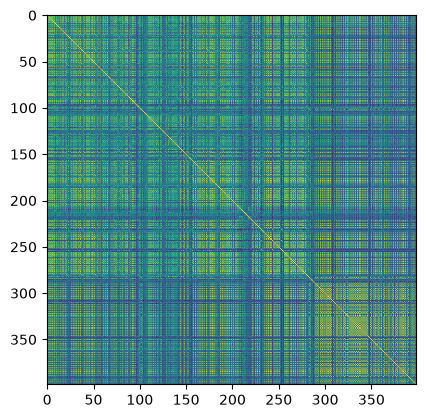

In [52]:
# Manual diarization via embedding
# Get speaker start and stop times for extended 
speakers, speaker_start_times, speaker_stop_times = get_transcript_speakers(transcript)

# Get an encoding model for feature extraction
enc_model = EncDecSpeakerLabelModel.from_pretrained(model_name="titanet_small").eval() # type: ignore
device = next(enc_model.parameters()).device
# load the whole audio file
sample_frequency = 16000
audio, _ = librosa.load(audio_path, sr=sample_frequency)

# Get embeddings
embeddings = extract_speaker_segment_embeddings(audio, enc_model, speaker_start_times, speaker_stop_times, device, sample_frequency)
# Compute similarity and classify
similarity_mat = get_pairwise_similarity(embeddings)
distance_mat = 1-similarity_mat
plt.imshow(similarity_mat)

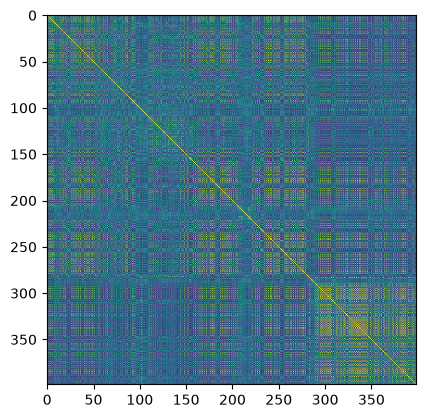

In [51]:
embedding_matrix = np.vstack(embeddings)
embedding_matrix = embedding_matrix - np.mean(embedding_matrix, axis=0, keepdims=True)
norms = np.linalg.norm(embedding_matrix, axis=1, keepdims=True)
norms[norms == 0] = 1e-12 
embedding_matrix = embedding_matrix / norms
cosine_sim_matrix = np.dot(embedding_matrix, embedding_matrix.T)
plt.imshow(cosine_sim_matrix)

In [53]:
# Cluster to get harmonized speaker labels
speaker_labels = cluster_embeddings(1-cosine_sim_matrix, 2)
print(speaker_labels)

[0 0 1 0 1 0 1 0 1 0 1 0 1 0 1 0 1 0 1 0 1 0 0 0 0 0 1 0 1 0 1 0 1 0 1 0 1
 0 0 0 1 0 1 0 1 0 1 0 1 1 0 1 0 0 0 1 0 1 0 0 0 1 0 1 0 1 0 0 0 1 0 1 0 1
 0 1 0 0 0 1 0 1 0 0 0 1 0 1 0 0 0 0 1 1 0 1 0 0 0 0 1 0 0 1 0 0 0 0 0 1 0
 1 0 1 0 1 0 1 0 1 0 0 0 1 0 0 0 0 0 1 0 0 0 0 0 0 1 0 1 0 0 0 0 0 1 0 0 0
 1 0 0 0 1 0 0 0 0 0 1 0 1 0 1 0 1 0 1 0 1 0 1 0 1 0 0 0 1 0 1 1 0 1 0 0 0
 0 0 1 0 1 0 1 0 1 0 1 0 1 0 1 0 1 0 1 0 1 0 1 0 1 0 1 0 0 0 0 0 0 0 0 0 0
 1 0 0 1 0 1 0 1 0 0 0 0 0 1 0 1 0 1 0 1 1 0 0 1 0 1 0 1 0 1 0 0 0 0 1 0 1
 0 1 0 0 1 1 0 1 0 1 0 1 0 1 0 1 0 1 1 0 1 0 0 0 0 1 0 0 0 0 1 0 1 0 1 0 1
 0 1 0 1 0 1 0 1 1 0 1 0 0 0 1 0 1 0 1 0 1 0 1 0 1 0 1 0 1 1 0 1 0 1 0 1 0
 1 0 1 0 1 1 0 1 0 1 0 1 0 1 0 0 0 1 0 1 0 1 1 0 1 0 1 0 1 0 0 1 0 1 0 1 0
 1 0 1 0 1 0 1 0 1 0 1 0 1 0 1 1 0 1 0 1 0 0 0 1 0 1 0 1 0]
